In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna xgboost

import os
import gc
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb

from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

# ==========================================
# CONFIGURAÇÕES
# ==========================================
SEED = 42
np.random.seed(SEED)
DATASET_PATH = "/content/drive/MyDrive/2026/ic/npz_files/utd_mhad_v2.npz"

# Tentar usar GPU se disponível
try:
    import torch
    if torch.cuda.is_available():
        DEVICE = 'cuda'
        print(" GPU Detectada: Usando aceleração no XGBoost.")
    else:
        DEVICE = 'cpu'
        print(" GPU não detectada. Usando CPU.")
except:
    DEVICE = 'cpu'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00
 GPU não detectada. Usando CPU.


In [3]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample

def load_data():
    data = np.load(DATASET_PATH)
    X_train = data['X_train']
    y_train = data['y_train']
    X_val = data['X_val']
    y_val = data['y_val']
    X_test = data['X_test']
    y_test = data['y_test']

    return X_train, y_train, X_val, y_val, X_test, y_test

# --- CARREGAR DADOS ---
X_train_raw, y_train_orig, X_val_raw, y_val_orig, X_test_raw, y_test_orig = load_data()

# CORREÇÃO: Usar LabelEncoder para garantir 0 a 26
le = LabelEncoder()
y_train = le.fit_transform(y_train_orig) # Transforma para 0..26
y_val = le.transform(y_val_orig)         # Transforma validação
y_test = le.transform(y_test_orig)       # Usa o mesmo mapeamento

# Verificar se deu certo
print("Classes originais:", np.unique(y_train_orig))
print("Classes transformadas:", np.unique(y_train))
print(f"Total de classes: {len(le.classes_)}")

# Atualizar o num_class dinamicamente
NUM_CLASSES = len(le.classes_)

def extract_statistical_features(X):
    # X shape esperado: (samples, time_steps, channels)
    # Extraindo: Média, Desvio Padrão, Max, Min
    mean = np.mean(X, axis=1)
    std = np.std(X, axis=1)
    max_val = np.max(X, axis=1)
    min_val = np.min(X, axis=1)

    # Concatenar (samples, channels*4)
    return np.hstack([mean, std, max_val, min_val])

def bootstrap_eval(model, X_test, y_test, n_iterations=100):
    stats_f1 = []
    stats_acc = []

    # Previsão única no conjunto original para agilizar
    y_pred = model.predict(X_test)

    # Para o bootstrap, re-amostramos os índices
    n_size = len(y_test)
    indices = np.arange(n_size)

    for _ in range(n_iterations):
        # Amostragem com reposição
        boot_idx = resample(indices, n_samples=n_size, replace=True, random_state=None)

        if len(np.unique(y_test[boot_idx])) < 2:
            continue # Evitar amostras com apenas 1 classe

        score_f1 = f1_score(y_test[boot_idx], y_pred[boot_idx], average='macro')
        score_acc = accuracy_score(y_test[boot_idx], y_pred[boot_idx])

        stats_f1.append(score_f1)
        stats_acc.append(score_acc)

    return (np.mean(stats_f1), np.percentile(stats_f1, 2.5), np.percentile(stats_f1, 97.5),
            np.mean(stats_acc), np.percentile(stats_acc, 2.5), np.percentile(stats_acc, 97.5))

Classes originais: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26]
Classes transformadas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26]
Total de classes: 27


Iniciando experimentos XGBoost no device: cpu...

--- Rodando: Raw_Default ---


[I 2026-04-21 03:03:49,592] A new study created in memory with name: no-name-4231c0dc-8117-493e-aae1-ecca2a30d805



--- Rodando: Raw_Optuna ---


[I 2026-04-21 03:33:43,747] Trial 0 finished with value: 0.5267574606463495 and parameters: {'n_estimators': 473, 'max_depth': 11, 'learning_rate': 0.011395264909455742, 'subsample': 0.7287530312299023, 'colsample_bytree': 0.7492065288360124, 'min_child_weight': 4}. Best is trial 0 with value: 0.5267574606463495.
[I 2026-04-21 03:48:01,950] Trial 1 finished with value: 0.5241653823462102 and parameters: {'n_estimators': 587, 'max_depth': 10, 'learning_rate': 0.09258899148362673, 'subsample': 0.876322128232865, 'colsample_bytree': 0.6850422148385239, 'min_child_weight': 8}. Best is trial 0 with value: 0.5267574606463495.
[I 2026-04-21 03:56:09,856] Trial 2 finished with value: 0.5509892540284698 and parameters: {'n_estimators': 123, 'max_depth': 15, 'learning_rate': 0.050329532921333325, 'subsample': 0.51451318835999, 'colsample_bytree': 0.6306411051206519, 'min_child_weight': 2}. Best is trial 2 with value: 0.5509892540284698.
[I 2026-04-21 04:23:50,651] Trial 3 finished with value: 0.

Melhores params: {'n_estimators': 399, 'max_depth': 3, 'learning_rate': 0.0336164060605692, 'subsample': 0.6474328120484603, 'colsample_bytree': 0.7178114984430275, 'min_child_weight': 3}

--- Rodando: Feat_Default ---


[I 2026-04-21 09:08:32,223] A new study created in memory with name: no-name-7a225f23-cfce-4475-b541-cb90800aa7ca



--- Rodando: Feat_Optuna ---


[I 2026-04-21 09:08:52,744] Trial 0 finished with value: 0.7489084989084989 and parameters: {'n_estimators': 160, 'max_depth': 6, 'learning_rate': 0.04209390686464876, 'subsample': 0.7939562921637532, 'colsample_bytree': 0.5497754650969215, 'min_child_weight': 1}. Best is trial 0 with value: 0.7489084989084989.
[I 2026-04-21 09:09:04,879] Trial 1 finished with value: 0.8042112571524336 and parameters: {'n_estimators': 190, 'max_depth': 13, 'learning_rate': 0.03278182433095077, 'subsample': 0.6166308855429967, 'colsample_bytree': 0.5069620177154912, 'min_child_weight': 5}. Best is trial 1 with value: 0.8042112571524336.
[I 2026-04-21 09:09:45,192] Trial 2 finished with value: 0.6858063746952636 and parameters: {'n_estimators': 622, 'max_depth': 7, 'learning_rate': 0.024562761947675985, 'subsample': 0.9996004208045535, 'colsample_bytree': 0.5213714257468749, 'min_child_weight': 2}. Best is trial 1 with value: 0.8042112571524336.
[I 2026-04-21 09:09:52,749] Trial 3 finished with value: 0.

Melhores params: {'n_estimators': 190, 'max_depth': 13, 'learning_rate': 0.03278182433095077, 'subsample': 0.6166308855429967, 'colsample_bytree': 0.5069620177154912, 'min_child_weight': 5}


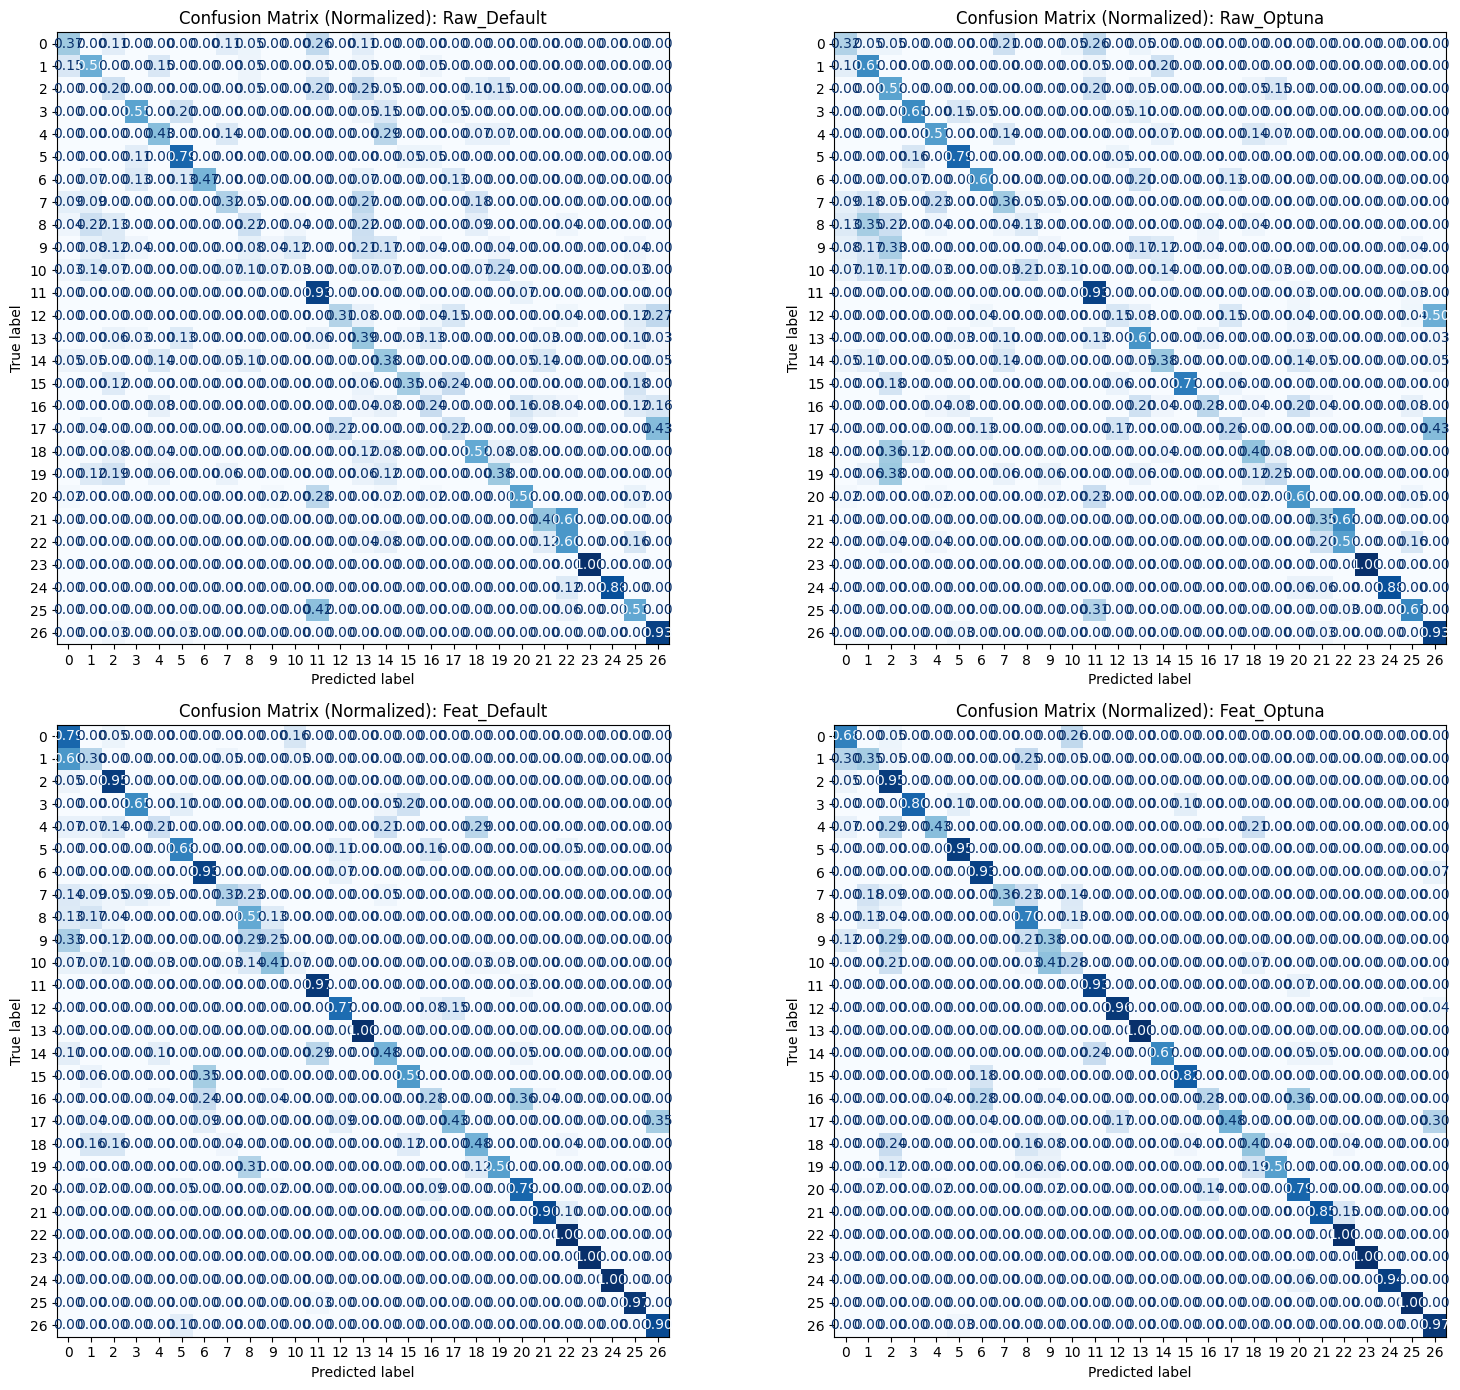


=== TABELA DE RESULTADOS (BOOTSTRAP) ===
       Scenario  Boot_F1_Mean  Boot_Acc_Mean      Time_Sec
0   Raw_Default      0.445752       0.460096    277.621299
1    Raw_Optuna      0.485538       0.506742  21872.985256
2  Feat_Default      0.637448       0.667705      8.609912
3   Feat_Optuna      0.715079       0.730369    483.295511


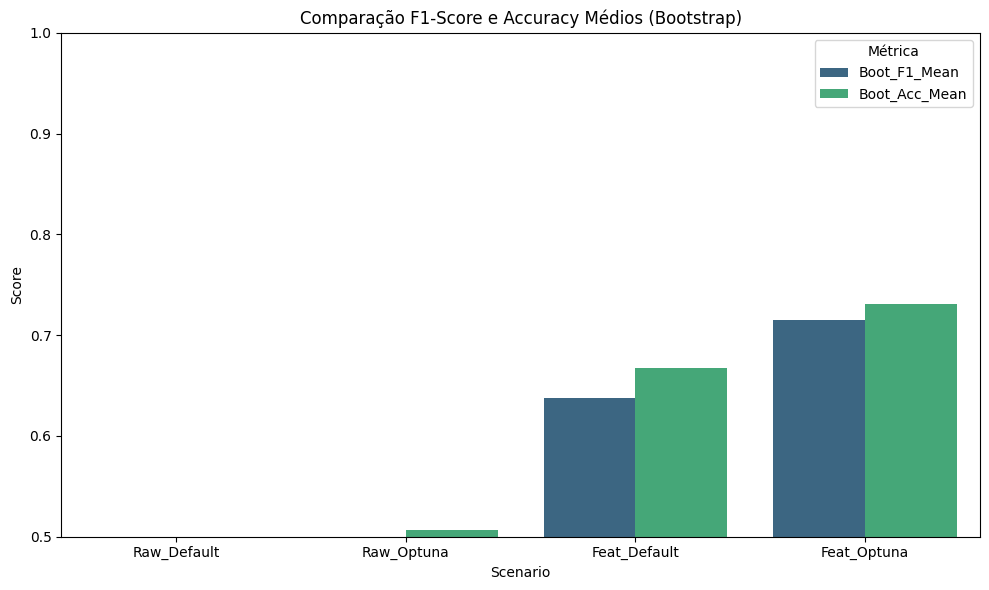

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def objective(trial, X_tr, y_tr, X_v, y_v):
    params = {
        'objective': 'multi:softmax',
        'num_class': NUM_CLASSES,
        'tree_method': 'hist', # Mais rápido
        'device': DEVICE,
        'verbosity': 0,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }

    model = xgb.XGBClassifier(**params, random_state=SEED)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    return f1_score(y_v, preds, average='macro')

# Preparar versões dos dados
# 1. RAW FLATTENED (XGBoost precisa de 2D)
X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_val_flat = X_val_raw.reshape(X_val_raw.shape[0], -1)
X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], -1)

# 2. FEATURES
X_train_feat = extract_statistical_features(X_train_raw)
X_val_feat = extract_statistical_features(X_val_raw)
X_test_feat = extract_statistical_features(X_test_raw)

# Lista de experimentos ordenados conforme solicitado
scenarios = [
    ("Raw_Default", X_train_flat, X_val_flat, X_test_flat, False),
    ("Raw_Optuna", X_train_flat, X_val_flat, X_test_flat, True),
    ("Feat_Default", X_train_feat, X_val_feat, X_test_feat, False),
    ("Feat_Optuna", X_train_feat, X_val_feat, X_test_feat, True)
]

results = []

print(f"Iniciando experimentos XGBoost no device: {DEVICE}...")

for name, X_tr, X_v, X_te, use_optuna in scenarios:
    print(f"\n--- Rodando: {name} ---")
    start_time = time.time()

    if use_optuna:
        # O conjunto de validação explícito é usado pelo Optuna, sem train_test_split
        study = optuna.create_study(direction='maximize')
        study.optimize(lambda trial: objective(trial, X_tr, y_train, X_v, y_val), n_trials=20) # 20 trials para teste rápido

        best_params = study.best_params
        best_params['objective'] = 'multi:softmax'
        best_params['num_class'] = NUM_CLASSES
        best_params['tree_method'] = 'hist'
        best_params['device'] = DEVICE

        model = xgb.XGBClassifier(**best_params, random_state=SEED)
        print(f"Melhores params: {study.best_params}")
    else:
        # Default Params
        model = xgb.XGBClassifier(
            objective='multi:softmax',
            num_class=NUM_CLASSES,
            tree_method='hist',
            device=DEVICE,
            random_state=SEED
        )

    # Treino Final
    model.fit(X_tr, y_train)

    # Previsão original para a matriz de confusão
    y_pred = model.predict(X_te)
    # Matriz normalizada por linha ('true' labels)
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    # Bootstrap apenas para avaliação de métricas (F1 e Acurácia)
    b_f1_mean, b_f1_low, b_f1_high, b_acc_mean, b_acc_low, b_acc_high = bootstrap_eval(model, X_te, y_test)

    elapsed = time.time() - start_time

    results.append({
        "Scenario": name,
        "Boot_F1_Mean": b_f1_mean,
        "Boot_Acc_Mean": b_acc_mean,
        "Time_Sec": elapsed,
        "CM": cm
    })

    gc.collect()

# --- EXIBIR MATRIZES DE CONFUSÃO ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()
for idx, res in enumerate(results):
    disp = ConfusionMatrixDisplay(confusion_matrix=res['CM'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False, values_format='.2f')
    axes[idx].set_title(f"Confusion Matrix (Normalized): {res['Scenario']}")
plt.tight_layout()
plt.show()

# --- RELATÓRIO FINAL E GRÁFICOS ---
df_res = pd.DataFrame(results).drop(columns=['CM'])
print("\n=== TABELA DE RESULTADOS (BOOTSTRAP) ===")
print(df_res[['Scenario', 'Boot_F1_Mean', 'Boot_Acc_Mean', 'Time_Sec']])

# Preparar dados para o Histograma Comparativo
df_melted = df_res.melt(id_vars='Scenario',
                        value_vars=['Boot_F1_Mean', 'Boot_Acc_Mean'],
                        var_name='Metric',
                        value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Scenario', y='Score', hue='Metric', palette='viridis')
plt.title("Comparação F1-Score e Accuracy Médios (Bootstrap)")
plt.ylim(0.5, 1.0)
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()